# Phase 3 — Heterogeneous Graph Construction 
**Input:** `Dataset/Processed/features.csv` (output from Phase 2)  
**Output:** `Dataset/Processed/graph_data.pt` (PyTorch Geometric HeteroData object)  

**What this notebook does:**
1. Load the feature matrix from Phase 2
2. Define 3 node types: User, IP, Service
3. Define 2 edge types: User→IP (`accesses`), User→Service (`calls`)
4. Build a `HeteroData` object with node features and edge indices
5. Attach anomaly labels to User nodes
6. Verify and visualize the graph structure
7. Save the graph object for Phase 4

## Cell 1 — Install Dependencies
Run this cell once if you have not installed PyTorch Geometric yet.  
After installation, **restart the kernel** before continuing.

In [12]:
# Only run this once. Comment it out after first successful install.
import sys

# Install PyTorch Geometric and its dependencies
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install torch_geometric
!{sys.executable} -m pip install networkx matplotlib

print("Installation complete. RESTART YOUR KERNEL before running Cell 2 onwards.")

Looking in indexes: https://download.pytorch.org/whl/cpu

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Installation complete. RESTART YOUR KERNEL before running Cell 2 onwards.


## Cell 2 — Imports & Load Data

In [13]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import os


# update these paths to match your local setup
INPUT_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/features_enriched.csv")
OUTPUT_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt")

df = pd.read_csv(INPUT_PATH)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded shape: (1000, 29)
Columns: ['userName_enc', 'sourceIPAddress_enc', 'eventSource_enc', 'eventName_enc', 'type_enc', 'sessionContext.attributes.mfaAuthenticated_enc', 'sessionContext.sessionIssuer.type_enc', 'errorCode_enc', 'eventType_enc', 'readOnly_enc', 'event_hour', 'event_dayofweek', 'is_weekend', 'is_off_hours', 'action_count', 'unique_ips', 'unique_services', 'unique_events', 'error_rate', 'off_hours_rate', 'weekend_rate', 'readonly_ratio', 'is_anomaly', 'avg_flow_duration', 'avg_pkt_len', 'avg_flow_bytes_s', 'network_attack_rate', 'global_bot_rate', 'global_bruteforce_rate']


## Cell 3 — Build Node ID Mappings
Each unique User, IP, and Service gets a contiguous integer ID starting from 0.  
This is required by PyTorch Geometric — edge indices must reference these integer IDs.

Graph schema:
- **Node types:** User (identity), IP (network bridge), Service (target/eventSource)
- **Edge types:** User →[accesses]→ IP, User →[calls]→ Service

In [14]:
# Re-read from phase 1 output to get original string columns for node mapping
PHASE1_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/df_identity_clean.csv")
df_raw = pd.read_csv(PHASE1_PATH)

# Build unique node sets
unique_users = df_raw['userName'].dropna().unique()
unique_ips = df_raw['sourceIPAddress'].dropna().unique()
unique_services = df_raw['eventSource'].dropna().unique()

# Create string -> integer mappings
user_to_id = {name: idx for idx, name in enumerate(unique_users)}
ip_to_id = {ip: idx for idx, ip in enumerate(unique_ips)}
service_to_id = {svc: idx for idx, svc in enumerate(unique_services)}

print(f"Node counts:")
print(f"  User nodes:    {len(user_to_id)}")
print(f"  IP nodes:      {len(ip_to_id)}")
print(f"  Service nodes: {len(service_to_id)}")

print(f"\nUser node IDs:")
for name, idx in user_to_id.items():
    print(f"  [{idx}] {name}")

print(f"\nService node IDs:")
for svc, idx in service_to_id.items():
    print(f"  [{idx}] {svc}")

Node counts:
  User nodes:    3
  IP nodes:      14
  Service nodes: 22

User node IDs:
  [0] bert-jan
  [1] Unknown
  [2] benjamin

Service node IDs:
  [0] iam.amazonaws.com
  [1] ec2.amazonaws.com
  [2] sts.amazonaws.com
  [3] s3.amazonaws.com
  [4] secretsmanager.amazonaws.com
  [5] kms.amazonaws.com
  [6] ssm.amazonaws.com
  [7] cloudtrail.amazonaws.com
  [8] logs.amazonaws.com
  [9] account.amazonaws.com
  [10] health.amazonaws.com
  [11] notifications.amazonaws.com
  [12] route53resolver.amazonaws.com
  [13] ram.amazonaws.com
  [14] ce.amazonaws.com
  [15] rds.amazonaws.com
  [16] lambda.amazonaws.com
  [17] rolesanywhere.amazonaws.com
  [18] resource-explorer-2.amazonaws.com
  [19] securityhub.amazonaws.com
  [20] guardduty.amazonaws.com
  [21] servicecatalog-appregistry.amazonaws.com


## Cell 4 — Build Node Feature Tensors
Each node type needs a feature matrix of shape `[num_nodes, num_features]`.  
- **User nodes** get the behavioral profile features from Phase 2 (action_count, error_rate, etc.)
- **IP nodes** get a simple one-hot-style feature: how many times they appear in the logs
- **Service nodes** get a frequency count feature as well

In [ ]:
# USER NODE FEATURES
# The behavioral profile columns from Phase 2
USER_FEATURE_COLS = [
    'action_count',
    'unique_ips',
    'unique_services',
    'unique_events',
    'error_rate',
    'off_hours_rate',
    'weekend_rate',
    'readonly_ratio',
]

# Aggregate per user (all rows for same user have same profile values — just take first)
user_features_df = df.merge(
    pd.DataFrame({'userName': list(user_to_id.keys()), 'user_node_id': list(user_to_id.values())}),
    left_on='userName_enc',
    right_on='user_node_id',
    how='left'
)

# Get one feature row per user, ordered by user_node_id
# We do this by taking the first occurrence of each userName_enc value
user_feat_matrix = (
    df.groupby('userName_enc')[USER_FEATURE_COLS]
    .first()
    .sort_index()
    .values
)
x_user = torch.tensor(user_feat_matrix, dtype=torch.float)
print(f"User feature tensor shape: {x_user.shape}  (num_users x num_features)")

# IP NODE FEATURES
# Feature: normalized access frequency
ip_counts = df_raw['sourceIPAddress'].value_counts()
ip_freq = np.array([
    ip_counts.get(ip, 0) for ip in unique_ips
], dtype=np.float32)

ip_freq = ip_freq / ip_freq.max()  # normalize to [0, 1]
x_ip = torch.tensor(ip_freq.reshape(-1, 1), dtype=torch.float)
print(f"IP feature tensor shape:   {x_ip.shape}  (num_ips x 1)")

# SERVICE NODE FEATURES
# Feature: normalized call frequency
svc_counts = df_raw['eventSource'].value_counts()
svc_freq = np.array([
    svc_counts.get(svc, 0) for svc in unique_services
], dtype=np.float32)

svc_freq = svc_freq / svc_freq.max()  # normalize to [0, 1]
x_service = torch.tensor(svc_freq.reshape(-1, 1), dtype=torch.float)
print(f"Service feature tensor:    {x_service.shape}  (num_services x 1)")

User feature tensor shape: torch.Size([3, 8])  (num_users x num_features)
IP feature tensor shape:   torch.Size([14, 1])  (num_ips x 1)
Service feature tensor:    torch.Size([22, 1])  (num_services x 1)


In [24]:
# Viewing User Features with column names
user_view = pd.DataFrame(x_user.numpy(), columns=USER_FEATURE_COLS)
print("User Feature Matrix:")
print(user_view)

# Viewing IP and Service Features
# Since these only have 1 column, we can just label it 'frequency'
ip_view = pd.DataFrame(x_ip.numpy(), columns=['normalized_freq'])
print("\nIP Feature Matrix (First 5):")
print(ip_view.head())

# Create a DataFrame using the list of unique services as the index
service_view = pd.DataFrame(
    x_service.numpy(), 
    index=unique_services, 
    columns=['normalized_usage_freq']
)

# Sort by usage to see the most accessed services at the top
print("Service Node Feature View (Top 10):")
print(service_view.sort_values(by='normalized_usage_freq', ascending=False).head(10))

User Feature Matrix:
   action_count  unique_ips  unique_services  unique_events  error_rate  \
0       0.01599        1.00              0.0            0.0    1.000000   
1       0.00000        0.00              0.0            0.0    0.113197   
2       1.00000        0.25              1.0            1.0    0.000000   

   off_hours_rate  weekend_rate  readonly_ratio  
0             0.0           0.0        0.491498  
1             0.0           0.0        1.000000  
2             0.0           0.0        0.000000  

IP Feature Matrix (First 5):
   normalized_freq
0         1.000000
1         0.002667
2         0.086667
3         0.068000
4         0.001333
Service Node Feature View (Top 10):
                              normalized_usage_freq
ec2.amazonaws.com                          1.000000
ssm.amazonaws.com                          0.571429
secretsmanager.amazonaws.com               0.344720
iam.amazonaws.com                          0.332298
kms.amazonaws.com                     

## Cell 5 — Build Edge Index Tensors
Edges are stored as a tensor of shape `[2, num_edges]`.  
Row 0 = source node IDs, Row 1 = destination node IDs.  
Each row in the event log becomes one edge (or two — one User→IP, one User→Service).

In [ ]:
# Map raw string values to node integer IDs
df_raw['user_node_id'] = df_raw['userName'].map(user_to_id)
df_raw['ip_node_id'] = df_raw['sourceIPAddress'].map(ip_to_id)
df_raw['service_node_id'] = df_raw['eventSource'].map(service_to_id)

# Drop rows where any mapping failed (shouldn't happen, but safety check)
df_edges = df_raw.dropna(subset=['user_node_id', 'ip_node_id', 'service_node_id']).copy()
df_edges = df_edges.astype({'user_node_id': int, 'ip_node_id': int, 'service_node_id': int})

# EDGE TYPE 1: User -> IP (user accesses IP)
user_ip_src = torch.tensor(df_edges['user_node_id'].values, dtype=torch.long)
user_ip_dst = torch.tensor(df_edges['ip_node_id'].values,   dtype=torch.long)
edge_index_user_ip = torch.stack([user_ip_src, user_ip_dst], dim=0)

# EDGE TYPE 2: User -> Service (user calls service)
user_svc_src = torch.tensor(df_edges['user_node_id'].values,    dtype=torch.long)
user_svc_dst = torch.tensor(df_edges['service_node_id'].values, dtype=torch.long)
edge_index_user_svc = torch.stack([user_svc_src, user_svc_dst], dim=0)

print(f"Edge type User->IP:      {edge_index_user_ip.shape}   (2 x num_edges)")
print(f"Edge type User->Service: {edge_index_user_svc.shape}   (2 x num_edges)")
print(f"Total edges: {edge_index_user_ip.shape[1] + edge_index_user_svc.shape[1]}")

Edge type User->IP:      torch.Size([2, 1000])   (2 x num_edges)
Edge type User->Service: torch.Size([2, 1000])   (2 x num_edges)
Total edges: 2000


## Cell 6 — Attach Anomaly Labels to User Nodes
Labels are attached at the **User node level**, not the edge level.  
A user is labeled anomalous (1) if any of their events was flagged in Phase 1.

In [17]:
# Get max anomaly label per user, ordered by user_node_id
user_labels = (
    df_raw.groupby('user_node_id')['is_anomaly']
    .max()
    .sort_index()
    .values
)
y_user = torch.tensor(user_labels, dtype=torch.long)

print("User node labels:")
for name, uid in user_to_id.items():
    label = y_user[uid].item()
    status = 'ANOMALY' if label == 1 else 'Normal'
    print(f"  [{uid}] {name:45s} -> {status}")

print(f"\nLabel tensor shape: {y_user.shape}")

User node labels:
  [0] bert-jan                                      -> ANOMALY
  [1] Unknown                                       -> ANOMALY
  [2] benjamin                                      -> Normal

Label tensor shape: torch.Size([3])


## Cell 7 — Assemble HeteroData Object
This is the final graph object that will be fed into the HGNN model in Phase 4.  
It follows the PyTorch Geometric `HeteroData` format.

In [ ]:
graph = HeteroData()

# Node features
graph['user'].x = x_user
graph['ip'].x = x_ip
graph['service'].x = x_service

# Node labels (only User nodes have labels for classification)
graph['user'].y = y_user

# Edge indices
# Naming convention in PyG: ('src_type', 'relation', 'dst_type')
graph['user', 'accesses', 'ip'].edge_index = edge_index_user_ip
graph['user', 'calls', 'service'].edge_index = edge_index_user_svc

# Summary
print("HeteroData graph summary:")
print(graph)
print()
print(f"User node feature shape:    {graph['user'].x.shape}")
print(f"IP node feature shape:      {graph['ip'].x.shape}")
print(f"Service node feature shape: {graph['service'].x.shape}")
print(f"User labels shape:          {graph['user'].y.shape}")
print(f"User->IP edges:             {graph['user', 'accesses', 'ip'].edge_index.shape}")
print(f"User->Service edges:        {graph['user', 'calls', 'service'].edge_index.shape}")

HeteroData graph summary:
HeteroData(
  user={
    x=[3, 8],
    y=[3],
  },
  ip={ x=[14, 1] },
  service={ x=[22, 1] },
  (user, accesses, ip)={ edge_index=[2, 1000] },
  (user, calls, service)={ edge_index=[2, 1000] }
)

User node feature shape:    torch.Size([3, 8])
IP node feature shape:      torch.Size([14, 1])
Service node feature shape: torch.Size([22, 1])
User labels shape:          torch.Size([3])
User->IP edges:             torch.Size([2, 1000])
User->Service edges:        torch.Size([2, 1000])


## Cell 8 — Validate Graph
PyTorch Geometric has a built-in validator. Any error here must be fixed before Phase 4.

In [19]:
from torch_geometric.utils import to_networkx

# Built-in PyG validation
# This checks: edge indices are within bounds, no negative indices, etc.
try:
    graph.validate(raise_on_error=True)
    print("Graph validation PASSED. No structural errors found.")
except Exception as e:
    print(f"Graph validation FAILED: {e}")

# Check node/edge counts manually
print(f"\nNode counts:")
print(f"  user:    {graph['user'].num_nodes}")
print(f"  ip:      {graph['ip'].num_nodes}")
print(f"  service: {graph['service'].num_nodes}")
print(f"\nEdge counts:")
print(f"  user->ip:      {graph['user', 'accesses', 'ip'].num_edges}")
print(f"  user->service: {graph['user', 'calls', 'service'].num_edges}")

# Confirm max edge index doesn't exceed node count (most common bug)
max_user_in_ip_edges  = edge_index_user_ip[0].max().item()
max_user_in_svc_edges = edge_index_user_svc[0].max().item()
print(f"\nMax user index in User->IP edges:      {max_user_in_ip_edges}  (should be < {len(user_to_id)})")
print(f"Max user index in User->Service edges: {max_user_in_svc_edges}  (should be < {len(user_to_id)})")

Graph validation PASSED. No structural errors found.

Node counts:
  user:    3
  ip:      14
  service: 22

Edge counts:
  user->ip:      1000
  user->service: 1000

Max user index in User->IP edges:      2  (should be < 3)
Max user index in User->Service edges: 2  (should be < 3)


## Cell 9 — Visualize Graph with NetworkX
This renders a simplified view of the graph to confirm the structure visually.  
Red nodes = anomalous users. Blue = normal users. Orange = IP nodes. Green = Service nodes.

/var/folders/s5/ck6frb1j5sq98srb5ml9wg9m0000gn/T/ipykernel_10552/3863650544.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


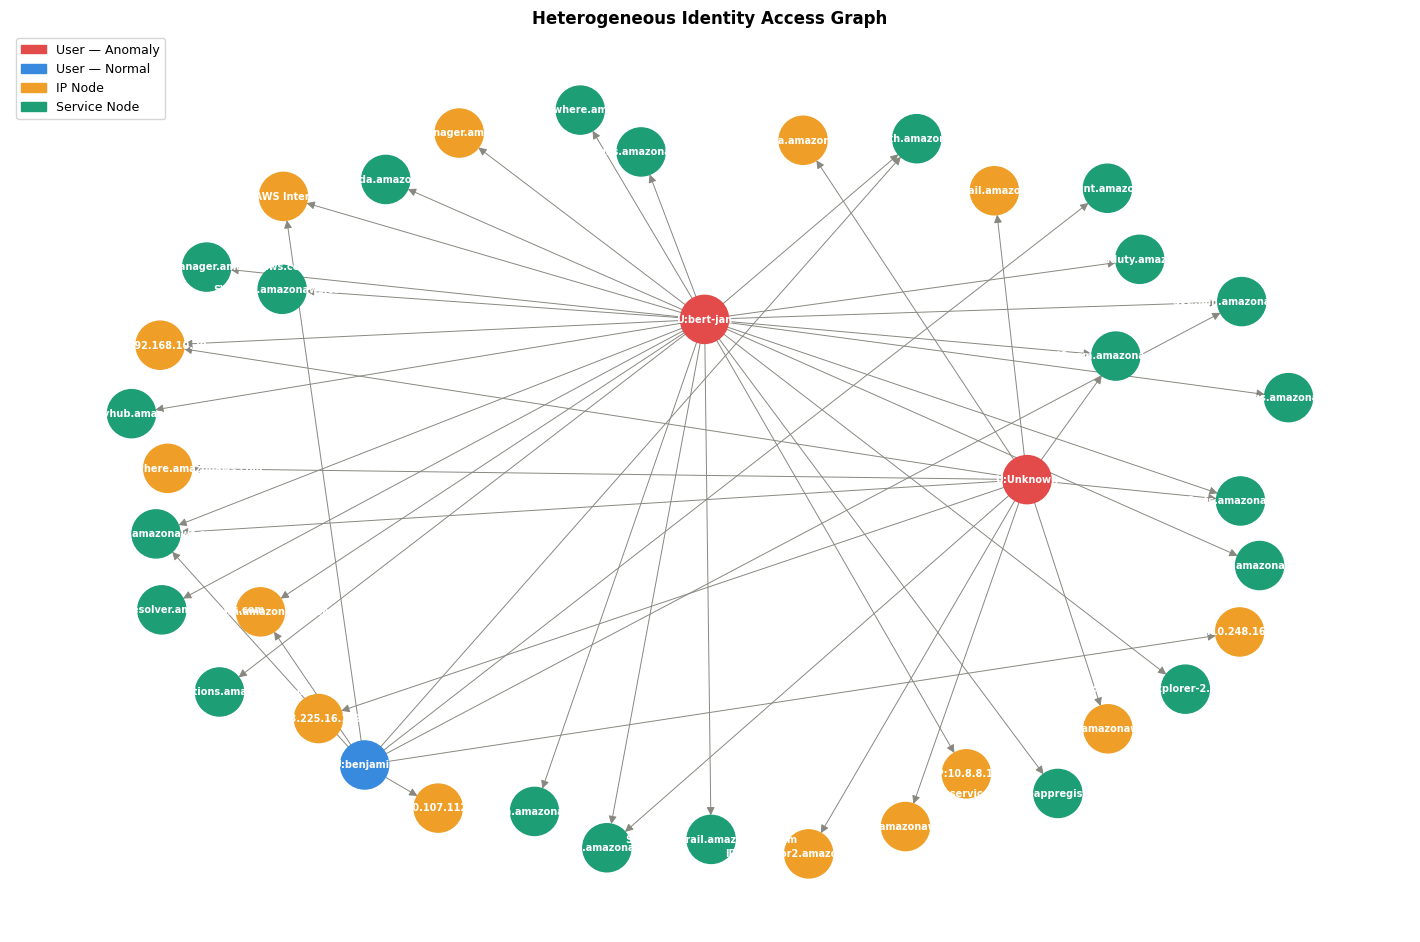

Graph visualization saved.


In [25]:
G = nx.DiGraph()

# Add User nodes
for name, uid in user_to_id.items():
    label = y_user[uid].item()
    G.add_node(f"U:{name}", node_type='user', anomaly=label)

# Add IP nodes
for ip, iid in ip_to_id.items():
    G.add_node(f"IP:{ip}", node_type='ip')

# Add Service nodes
for svc, sid in service_to_id.items():
    G.add_node(f"SVC:{svc}", node_type='service')

# Add edges (deduplicated for visualization clarity)
for _, row in df_raw[['userName', 'sourceIPAddress', 'eventSource']].drop_duplicates().iterrows():
    G.add_edge(f"U:{row['userName']}",      f"IP:{row['sourceIPAddress']}",   edge_type='accesses')
    G.add_edge(f"U:{row['userName']}",      f"SVC:{row['eventSource']}",      edge_type='calls')

# Assign colors per node type
color_map = []
for node in G.nodes(data=True):
    ntype = node[1].get('node_type')
    if ntype == 'user':
        color_map.append('#E24B4A' if node[1].get('anomaly') == 1 else '#378ADD')
    elif ntype == 'ip':
        color_map.append('#EF9F27')
    else:
        color_map.append('#1D9E75')

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw(
    G, pos,
    node_color=color_map,
    with_labels=True,
    labels={n: n for n in G.nodes()},
    node_size=1200,
    font_size=7,
    font_color='white',
    font_weight='bold',
    arrows=True,
    arrowsize=12,
    edge_color='#888780',
    width=0.7,
)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#E24B4A', label='User — Anomaly'),
    Patch(color='#378ADD', label='User — Normal'),
    Patch(color='#EF9F27', label='IP Node'),
    Patch(color='#1D9E75', label='Service Node'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9)
plt.title("Heterogeneous Identity Access Graph", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/graph_visualization.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graph visualization saved.")

## Cell 10 — Save Graph Object

In [21]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

torch.save(graph, OUTPUT_PATH)

# Verify it can be loaded back correctly
graph_check = torch.load(OUTPUT_PATH, weights_only=False)
print("Save and reload verification:")
print(graph_check)
print(f"\nSaved to: {OUTPUT_PATH}")
print("Phase 3 complete. Ready for Phase 4 — HGNN Model.")

Save and reload verification:
HeteroData(
  user={
    x=[3, 8],
    y=[3],
  },
  ip={ x=[14, 1] },
  service={ x=[22, 1] },
  (user, accesses, ip)={ edge_index=[2, 1000] },
  (user, calls, service)={ edge_index=[2, 1000] }
)

Saved to: /Users/philberttan/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt
Phase 3 complete. Ready for Phase 4 — HGNN Model.
